# 04 — Baselines

**input:** `data/movies.pkl`, `data/embeddings.npy`, `data/results_ours.pkl`

**Two baselines:**
1. **Random partition** — splits the candidate set randomly
2. **Taxonomy (category-based)** — splits by genre

**Goal:** show that semantic clustering outperforms both baselines

**output:** `data/results_random.pkl`, `data/results_taxonomy.pkl`, comparison plot

In [1]:
import numpy as np
import pandas as pd
import pickle, sys
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

sys.path.append(str(Path('../')))
from query_templates import get_query_for_movie

DATA_DIR    = Path('../data')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

movies     = pd.read_pickle(DATA_DIR / 'movies.pkl')
embeddings = np.load(DATA_DIR / 'embeddings.npy')
sbert      = SentenceTransformer('all-MiniLM-L6-v2')

with open(DATA_DIR / 'results_ours.pkl', 'rb') as f:
    ours = pickle.load(f)
df_ours      = ours['df']
target_items = ours['target_items']

STOP_SIZE = 5
MAX_TURNS = 6
TOP_N     = 500   # all methods start from the same top-500 pool

np.random.seed(42)
print(f'Loaded {len(target_items)} target items')
print('imports OK')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded 200 target items
imports OK


### Shared helper functions

In [2]:
import sys
sys.path.insert(0, '../src')

from core import (
    entropy,
    expected_entropy,
    information_gain,
    adaptive_k,
    simulated_user,
    retrieve_candidates,
    cluster_candidates
)

def make_query_embedding(target_idx):
    genres     = movies.iloc[target_idx]['genres']
    query_text = get_query_for_movie(genres)
    query_emb  = sbert.encode(query_text, normalize_embeddings=True)
    return query_emb

print('functions OK')


functions OK


### Baseline 1 — Random Partition

In [3]:
def random_partition(candidate_indices, k):
    shuffled = candidate_indices.copy()
    np.random.shuffle(shuffled)
    chunks = np.array_split(shuffled, k)
    return [list(c) for c in chunks if len(c) > 0]


def run_random(target_idx, stop_size=STOP_SIZE, max_turns=MAX_TURNS):
    # ── same retrieval used by our method ──────────
    query_emb = make_query_embedding(target_idx)
    C = retrieve_candidates(query_emb, embeddings, top_n=TOP_N)
    if target_idx not in C:
        C.append(target_idx)

    entropy_trace = [entropy(C)]
    ig_trace = []
    turn = 0

    while len(C) > stop_size and turn < max_turns:
        k = adaptive_k(len(C))
        partition = random_partition(C, k)
        ig_trace.append(information_gain(C, partition))
        chosen = simulated_user(partition, target_idx)
        C = partition[chosen]
        turn += 1
        entropy_trace.append(entropy(C))

    return {
        'turns':         turn,
        'final_size':    len(C),
        'success':       target_idx in C,
        'entropy_trace': entropy_trace,
        'ig_trace':      ig_trace,
    }


results_random = []
for t in tqdm(target_items, desc='Baseline: Random'):
    r = run_random(int(t))
    r['target_idx'] = int(t)
    results_random.append(r)

df_random = pd.DataFrame(results_random)
print(f'Avg turns     : {df_random["turns"].mean():.2f}')
print(f'Avg final size: {df_random["final_size"].mean():.2f}')
print(f'Success rate  : {df_random["success"].mean():.3f}')


Baseline: Random: 100%|██████████| 200/200 [00:04<00:00, 44.01it/s]

Avg turns     : 4.00
Avg final size: 4.04
Success rate  : 1.000


### Baseline 2 — Taxonomy (Genre-based)

In [4]:
ALL_GENRES = [
    'Action', 'Adventure', 'Animation', "Children's", 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
    'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
    'Thriller', 'War', 'Western'
]

movie_primary_genre = movies['genres'].str.split('|').str[0].values


def taxonomy_partition(candidate_indices):
    groups = {}
    for idx in candidate_indices:
        genre = movie_primary_genre[idx]
        if genre not in groups:
            groups[genre] = []
        groups[genre].append(idx)
    partition = [g for g in groups.values() if g]
    if len(partition) > 6:
        partition = sorted(partition, key=len, reverse=True)[:6]
    return partition


def run_taxonomy(target_idx, stop_size=STOP_SIZE, max_turns=MAX_TURNS):
    # ── same retrieval used by our method ──────────
    query_emb = make_query_embedding(target_idx)
    C = retrieve_candidates(query_emb, embeddings, top_n=TOP_N)
    if target_idx not in C:
        C.append(target_idx)

    entropy_trace = [entropy(C)]
    ig_trace = []
    turn = 0

    while len(C) > stop_size and turn < max_turns:
        partition = taxonomy_partition(C)
        if len(partition) <= 1:
            break
        ig_trace.append(information_gain(C, partition))
        chosen = simulated_user(partition, target_idx)
        C = partition[chosen]
        turn += 1
        entropy_trace.append(entropy(C))

    return {
        'turns':         turn,
        'final_size':    len(C),
        'success':       target_idx in C,
        'entropy_trace': entropy_trace,
        'ig_trace':      ig_trace,
    }


results_taxonomy = []
for t in tqdm(target_items, desc='Baseline: Taxonomy'):
    r = run_taxonomy(int(t))
    r['target_idx'] = int(t)
    results_taxonomy.append(r)

df_taxonomy = pd.DataFrame(results_taxonomy)
print(f'Avg turns     : {df_taxonomy["turns"].mean():.2f}')
print(f'Avg final size: {df_taxonomy["final_size"].mean():.2f}')
print(f'Success rate  : {df_taxonomy["success"].mean():.3f}')


Baseline: Taxonomy: 100%|██████████| 200/200 [00:04<00:00, 44.64it/s]

Avg turns     : 1.00
Avg final size: 176.40
Success rate  : 0.945


### Comparison of three methods

Candidate set size after K turns (lower = better):

 Turns    Semantic    Taxonomy      Random
------------------------------------------
     1       113.1       176.4       100.2
     2        32.0       176.4        24.2
     3        12.5       176.4         8.1
     4         6.1       176.4         4.0
     5         4.2       176.4         4.0
     6         3.6       176.4         4.0

          Method  Avg Final Size  Success Rate  Avg IG/Turn
 Semantic (ours)           3.555         1.000        1.608
Taxonomy (genre)         176.400         0.945        2.186
          Random           4.035         1.000        1.739


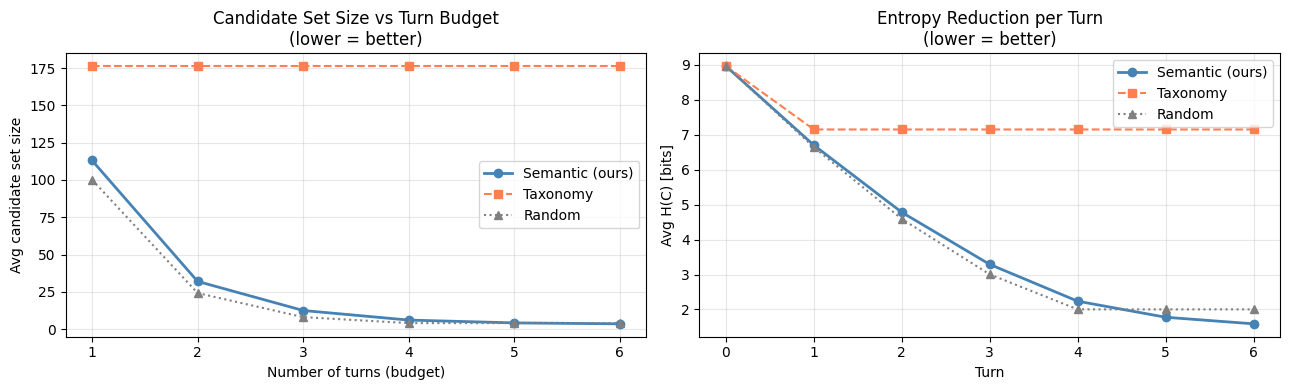

In [5]:
# ── Fixed-turn evaluation ────────────────────────────────
# Instead of avg turns, we ask:
# after a fixed K turns, how small is the candidate set?

def size_at_turn(df_results, turn_k):
    """
    Candidate set size after turn_k turns.
    If the loop stopped earlier, holds the last known size.
    """
    sizes = []
    for _, row in df_results.iterrows():
        trace = row['entropy_trace']
        if len(trace) > turn_k:
            # H = log2(|C|) so |C| = 2^H
            sizes.append(2 ** trace[turn_k])
        else:
            sizes.append(row['final_size'])
    return np.mean(sizes)


# ── Table 1: Fixed-budget comparison ────────────────────
print('Candidate set size after K turns (lower = better):')
print()
print(f'{'Turns':>6}  {'Semantic':>10}  {'Taxonomy':>10}  {'Random':>10}')
print('-' * 42)
for k in range(1, MAX_TURNS + 1):
    s_our = size_at_turn(df_ours, k)
    s_tax = size_at_turn(df_taxonomy, k)
    s_ran = size_at_turn(df_random, k)
    print(f'{k:>6}  {s_our:>10.1f}  {s_tax:>10.1f}  {s_ran:>10.1f}')

# ── Table 2: Summary ─────────────────────────────────────
print()
summary = pd.DataFrame({
    'Method':         ['Semantic (ours)', 'Taxonomy (genre)', 'Random'],
    'Avg Final Size': [df_ours['final_size'].mean(),
                       df_taxonomy['final_size'].mean(),
                       df_random['final_size'].mean()],
    'Success Rate':   [df_ours['success'].mean(),
                       df_taxonomy['success'].mean(),
                       df_random['success'].mean()],
    'Avg IG/Turn':    [
        np.mean([np.mean(r) for r in df_ours['ig_trace'] if r]),
        np.mean([np.mean(r) for r in df_taxonomy['ig_trace'] if r]),
        np.mean([np.mean(r) for r in df_random['ig_trace'] if r]),
    ],
})
print(summary.round(3).to_string(index=False))

# ── Plot 1: Candidate size after K turns ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

k_range = range(1, MAX_TURNS + 1)
our_sizes = [size_at_turn(df_ours, k)      for k in k_range]
tax_sizes = [size_at_turn(df_taxonomy, k)  for k in k_range]
ran_sizes = [size_at_turn(df_random, k)    for k in k_range]

axes[0].plot(k_range, our_sizes, marker='o', color='steelblue', label='Semantic (ours)', linewidth=2)
axes[0].plot(k_range, tax_sizes, marker='s', color='coral',     label='Taxonomy', linestyle='--')
axes[0].plot(k_range, ran_sizes, marker='^', color='gray',      label='Random',   linestyle=':')
axes[0].set_xlabel('Number of turns (budget)')
axes[0].set_ylabel('Avg candidate set size')
axes[0].set_title('Candidate Set Size vs Turn Budget\n(lower = better)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Plot 2: Entropy reduction per turn ───────────────────
def mean_entropy_trace(df_results, max_turns):
    traces = df_results['entropy_trace'].tolist()
    padded = [t + [t[-1]] * (max_turns + 1 - len(t)) for t in traces]
    return np.mean(padded, axis=0)

our_h  = mean_entropy_trace(df_ours, MAX_TURNS)
tax_h  = mean_entropy_trace(df_taxonomy, MAX_TURNS)
rand_h = mean_entropy_trace(df_random, MAX_TURNS)

x = range(len(our_h))
axes[1].plot(x, our_h,  marker='o', color='steelblue', label='Semantic (ours)', linewidth=2)
axes[1].plot(x, tax_h,  marker='s', color='coral',     label='Taxonomy', linestyle='--')
axes[1].plot(x, rand_h, marker='^', color='gray',      label='Random',   linestyle=':')
axes[1].set_xlabel('Turn')
axes[1].set_ylabel('Avg H(C) [bits]')
axes[1].set_title('Entropy Reduction per Turn\n(lower = better)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison.png', dpi=150)
plt.show()


### Save

In [6]:
with open(DATA_DIR / 'results_random.pkl', 'wb') as f:
    pickle.dump({'df': df_random}, f)

with open(DATA_DIR / 'results_taxonomy.pkl', 'wb') as f:
    pickle.dump({'df': df_taxonomy}, f)

print('Saved: results_random.pkl, results_taxonomy.pkl')
print('Saved: results/comparison.png')
print()
print('✅ notebook 04 complete')

Saved: results_random.pkl, results_taxonomy.pkl
Saved: results/comparison.png

✅ notebook 04 complete
